In [10]:
# Видаляємо стару копію (якщо вже клонували раніше)
!rm -rf deep

# Клонуємо особистий репозиторій з конспектами і матеріалами
# (репозиторій курсу goitacademy — лише для довідки, всі матеріали вже у PetraStill/deep)
!git clone https://github.com/PetraStill/deep.git

# Переходимо в директорію репозиторію
%cd deep

Cloning into 'deep'...
remote: Enumerating objects: 7347, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 7347 (delta 4), reused 9 (delta 3), pack-reused 7335 (from 4)
Receiving objects: 100% (7347/7347), 258.07 MiB | 49.61 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (7329/7329), done.
/kaggle/working/deep


In [ ]:
# Встановлюємо бібліотеку ultralytics для роботи з YOLO
# --upgrade гарантує встановлення останньої версії
!pip install --upgrade ultralytics

# ray[tune] — бібліотека для розподіленого підбору гіперпараметрів (потрібна в темі 14)
!pip install --upgrade -U "ray[tune]"

In [4]:
import warnings
warnings.filterwarnings("ignore")  # Вимикаємо попередження — щоб вивід був чистішим

import os       # Робота з файловою системою (шляхи, папки)
import re       # Регулярні вирази
import glob     # Пошук файлів за маскою
import random   # Генерація випадкових чисел (для відтворюваності)
import yaml     # Читання і запис YAML-конфігурацій

import numpy as np           # Числові операції, масиви
import pandas as pd          # Табличні дані, DataFrame

import matplotlib.pyplot as plt          # Візуалізація
from matplotlib.patches import Rectangle # Малювання прямокутників на графіках
import seaborn as sns                    # Розширена статистична візуалізація

from PIL import Image  # Завантаження і обробка зображень (Python Imaging Library)
import cv2             # OpenCV — зчитування, запис та обробка зображень

from ultralytics import YOLO  # Клас для завантаження і тренування YOLO-моделей

# Відображати графіки inline (у Jupyter/Colab)
%matplotlib inline

# Вимикаємо логування Weights & Biases (якщо wandb встановлено)
!wandb disabled

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
wandb: Updated settings file /kaggle/working/wandb/settings
W&B disabled.


In [5]:
class CFG:
    """
    Клас-контейнер для всіх гіперпараметрів і налаштувань тренування.
    Зберігання конфігурацій в одному місці полегшує відтворюваність і зміну параметрів.
    """

    # --- Режим дебагу ---
    DEBUG = False  # True: швидкі тести на малій частині датасету; False: повне тренування
    FRACTION = 0.05 if DEBUG else 1.0  # Частка датасету для тренування (5% у debug)
    SEED = 42  # Зафіксований seed для відтворюваності результатів

    # --- Класи ---
    CLASSES = [
        'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
        'NO-Safety Vest', 'Person', 'Safety Cone',
        'Safety Vest', 'machinery', 'vehicle'
    ]  # Список назв класів у порядку відповідно до анотацій
    NUM_CLASSES_TO_TRAIN = len(CLASSES)  # 10 — кількість класів

    # --- Параметри тренування ---
    EPOCHS = 3 if DEBUG else 70  # Кількість епох; 70 — для повного тренування
    BATCH_SIZE = 8   # Кількість зображень в одному батчі; 16 при більшій GPU-пам'яті

    # --- Модель ---
    BASE_MODEL = 'yolov9e'  # Вибір архітектури: yolov8n/s/m/l/x, yolov9c/e
    BASE_MODEL_WEIGHTS = f'{BASE_MODEL}.pt'  # Файл ваг: автозавантажується при першому запуску
    EXP_NAME = f'ppe_css_{EPOCHS}_epochs'  # Назва експерименту для збереження результатів

    # --- Оптимізатор та навчання ---
    OPTIMIZER = 'auto'     # auto: ultralytics обирає оптимізатор; або SGD/Adam/AdamW тощо
    LR = 1e-3              # Початковий learning rate (lr0)
    LR_FACTOR = 0.01       # Кінцевий lr = LR * LR_FACTOR → поступове зменшення
    WEIGHT_DECAY = 5e-4    # L2-регуляризація: штраф за великі ваги (запобігає overfitting)
    DROPOUT = 0.0          # Dropout rate: 0.0 — вимкнено
    PATIENCE = 20          # Early stopping: зупинити якщо 20 епох без покращення
    PROFILE = False        # Профілювання швидкості шарів (для дебагу)
    LABEL_SMOOTHING = 0.0  # Label smoothing: розм'якшення міток (0.0 — вимкнено)

     # --- Шляхи ---
    # Автоматично визначаємо середовище виконання:
    #   Colab:  після `git clone PetraStill/deep && %cd deep` → датасет у ./тема_7/
    #   Kaggle: після `!git clone PetraStill/deep` в /kaggle/working/ → датасет у ./deep/тема_7/
    #   Локально: шлях до папки тема_7 у клонованому репо
    CUSTOM_DATASET_DIR = './тема_7/'      # Colab / локально
    # CUSTOM_DATASET_DIR = './deep/тема_7/'  # Kaggle (розкоментуй якщо запускаєш на Kaggle)
    OUTPUT_DIR = './'  # Куди зберігати data.yaml і результати тренування

In [6]:
# Формуємо словник з усіма необхідними полями для YOLO
dict_file = {
    'train': os.path.join(CFG.CUSTOM_DATASET_DIR, 'train'),  # Шлях до train зображень
    'val':   os.path.join(CFG.CUSTOM_DATASET_DIR, 'valid'),  # Шлях до validation зображень
    'test':  os.path.join(CFG.CUSTOM_DATASET_DIR, 'test'),   # Шлях до test зображень
    'nc':    CFG.NUM_CLASSES_TO_TRAIN,                        # Кількість класів (nc = num_classes)
    'names': CFG.CLASSES                                      # Список назв класів
}

# Записуємо словник у файл data.yaml у директорії виводу
with open(os.path.join(CFG.OUTPUT_DIR, 'data.yaml'), 'w+') as file:
    yaml.dump(dict_file, file)

In [7]:
# Функція для зчитування YAML файлу
def read_yaml_file(file_path=CFG.CUSTOM_DATASET_DIR):
    with open(file_path, 'r') as file:
        try:
            data = yaml.safe_load(file)  # safe_load — безпечна альтернатива yaml.load()
            return data
        except yaml.YAMLError as e:
            print("Error reading YAML:", e)
            return None

# Функція для красивого виведення YAML
def print_yaml_data(data):
    formatted_yaml = yaml.dump(data, default_style=False)  # default_style=False → читабельний формат
    print(formatted_yaml)

# Зчитуємо і виводимо створений файл
file_path = os.path.join(CFG.OUTPUT_DIR, 'data.yaml')
yaml_data = read_yaml_file(file_path)

if yaml_data:
    print_yaml_data(yaml_data)

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: "./\u0442\u0435\u043C\u0430_7/test"
train: "./\u0442\u0435\u043C\u0430_7/train"
val: "./\u0442\u0435\u043C\u0430_7/valid"



Type:  <class 'PIL.JpegImagePlugin.JpegImageFile'> 

Shape:  (640, 640, 3) 



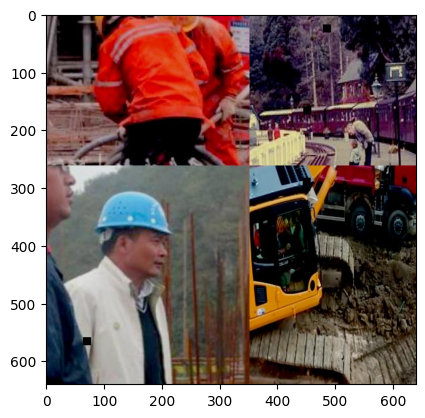

In [11]:
def display_image(image, print_info=True, hide_axis=False):
    """
    Відображає зображення — приймає як шлях до файлу, так і NumPy-масив.

    image:      str (шлях) або np.ndarray (масив пікселів)
    print_info: bool — виводити тип і розмір зображення
    hide_axis:  bool — приховати осі координат на графіку
    """
    if isinstance(image, str):       # Якщо передано шлях до файлу
        img = Image.open(image)       # Відкриваємо зображення через Pillow
        plt.imshow(img)               # Відображаємо на графіку
    elif isinstance(image, np.ndarray):  # Якщо передано масив NumPy (наприклад, від OpenCV)
        image = image[..., ::-1]      # Конвертуємо BGR → RGB (OpenCV зберігає в BGR!)
        img = Image.fromarray(image)  # Перетворюємо масив у PIL Image
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format")  # Невідомий формат

    if print_info:
        print('Type: ', type(img), '\n')
        print('Shape: ', np.array(img).shape, '\n')  # (висота, ширина, канали)

    if hide_axis:
        plt.axis('off')  # Вимикаємо осі — для чистішого відображення

    plt.show()


# Відображаємо конкретне тренувальне зображення
example_image_path = (
    CFG.CUSTOM_DATASET_DIR +
    'train/images/-2297-_png_jpg.rf.9fff3740d864fbec9cda50d783ad805e.jpg'
)
display_image(example_image_path, print_info=True, hide_axis=False)

In [12]:
def get_image_properties(image_path):
    """
    Повертає словник із властивостями зображення.

    image_path: str — шлях до файлу зображення
    Повертає: dict з ключами width, height, channels, dtype
    """
    img = cv2.imread(image_path)  # cv2 зчитує зображення як NumPy масив BGR

    if img is None:
        raise ValueError("Could not read image file")  # Файл не знайдено або пошкоджено

    properties = {
        "width":    img.shape[1],                                 # Ширина в пікселях
        "height":   img.shape[0],                                 # Висота в пікселях
        "channels": img.shape[2] if len(img.shape) == 3 else 1,  # 3 для RGB, 1 для grayscale
        "dtype":    img.dtype,                                    # Тип даних (uint8: 0–255)
    }
    return properties

img_properties = get_image_properties(example_image_path)
print(img_properties)

{'width': 640, 'height': 640, 'channels': 3, 'dtype': dtype('uint8')}


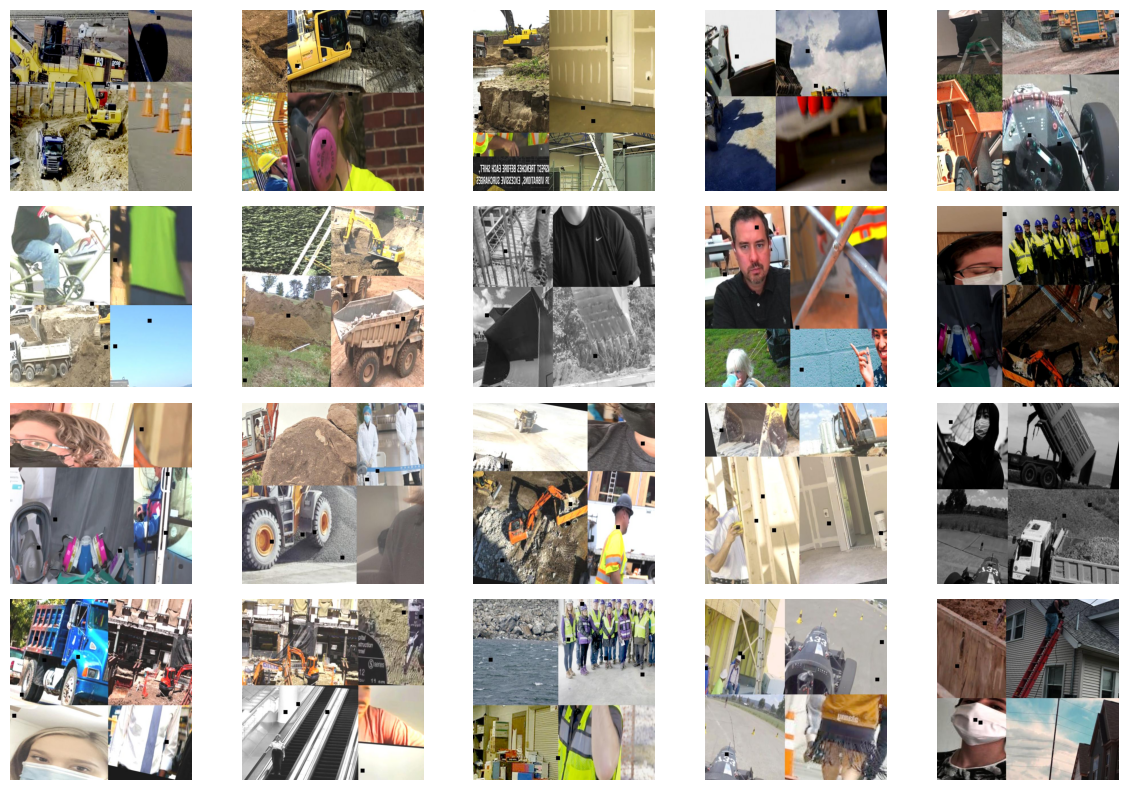

In [13]:
def plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED):
    """
    Відображає сітку випадково обраних зображень з теки.

    folder_path: str — шлях до теки із зображеннями
    num_images:  int — скільки зображень показати
    seed:        int — seed для відтворюваності вибірки
    """
    random.seed(seed)  # Фіксуємо seed — завжди отримуємо однакову вибірку

    # Збираємо всі файли зображень у теці за відомими розширеннями
    image_files = [
        f for f in os.listdir(folder_path)
        if f.endswith(('.jpg', '.png', '.jpeg', '.gif'))
    ]

    if len(image_files) < num_images:
        raise ValueError("Not enough images in the folder")

    # Випадково обираємо num_images файлів (без повторення)
    selected_files = random.sample(image_files, num_images)

    # Розраховуємо розміри сітки: 5 стовпців, решта — рядки
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols  # Округлення вгору
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i, file_name in enumerate(selected_files):
        img = Image.open(os.path.join(folder_path, file_name))

        # Вибираємо правильну вісь залежно від кількості рядків
        if num_rows == 1:
            ax = axes[i % num_cols]
        else:
            ax = axes[i // num_cols, i % num_cols]

        ax.imshow(img)
        ax.axis('off')  # Прибираємо осі — зображення без зайвих елементів

    # Видаляємо порожні підграфіки (якщо кількість не кратна num_cols)
    for i in range(num_images, num_rows * num_cols):
        if num_rows == 1:
            fig.delaxes(axes[i % num_cols])
        else:
            fig.delaxes(axes[i // num_cols, i % num_cols])

    plt.tight_layout()  # Автоматично підлаштовує відступи між підграфіками
    plt.show()


# Показуємо 20 випадкових зображень з тренувальної вибірки
plot_random_images_from_folder(
    folder_path=CFG.CUSTOM_DATASET_DIR + 'train/images/',
    num_images=20
)

In [14]:
# Словник: рядковий індекс → назва класу
class_idx = {str(i): CFG.CLASSES[i] for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

class_stat = {}   # Статистика по класах для кожної вибірки
data_len = {}     # Кількість файлів у кожній вибірці
class_info = []   # Зберігаємо для DataFrame

for mode in ['train', 'valid', 'test']:
    # Ініціалізуємо лічильник по кожному класу
    class_count = {CFG.CLASSES[i]: 0 for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

    path = os.path.join(CFG.CUSTOM_DATASET_DIR, mode, 'labels')

    for file in os.listdir(path):
        with open(os.path.join(path, file)) as f:
            lines = f.readlines()  # Кожна рядок = один об'єкт на зображенні

            # line[0] — перший символ рядка = клас (YOLO формат: клас x y w h)
            # set() — уникаємо повторного рахунку одного класу двічі на одному зображенні
            for cls in set([line[0] for line in lines]):
                class_count[class_idx[cls]] += 1

    data_len[mode] = len(os.listdir(path))
    class_stat[mode] = class_count
    class_info.append({'Mode': mode, **class_count, 'Data_Volume': data_len[mode]})

# Зберігаємо у DataFrame для зручного аналізу
dataset_stats_df = pd.DataFrame(class_info)

with pd.option_context('display.max_columns', None):  # Показуємо всі стовпці
    display(dataset_stats_df)

,Mode,Hardhat,Mask,NO-Hardhat,NO-Mask,NO-Safety Vest,Person,Safety Cone,Safety Vest,machinery,vehicle,Data_Volume
0,train,1314,1096,1380,1531,1864,2526,631,1319,2101,744,2605
1,valid,42,19,37,44,56,84,13,28,26,16,114
2,test,30,16,25,30,36,59,8,22,22,15,82


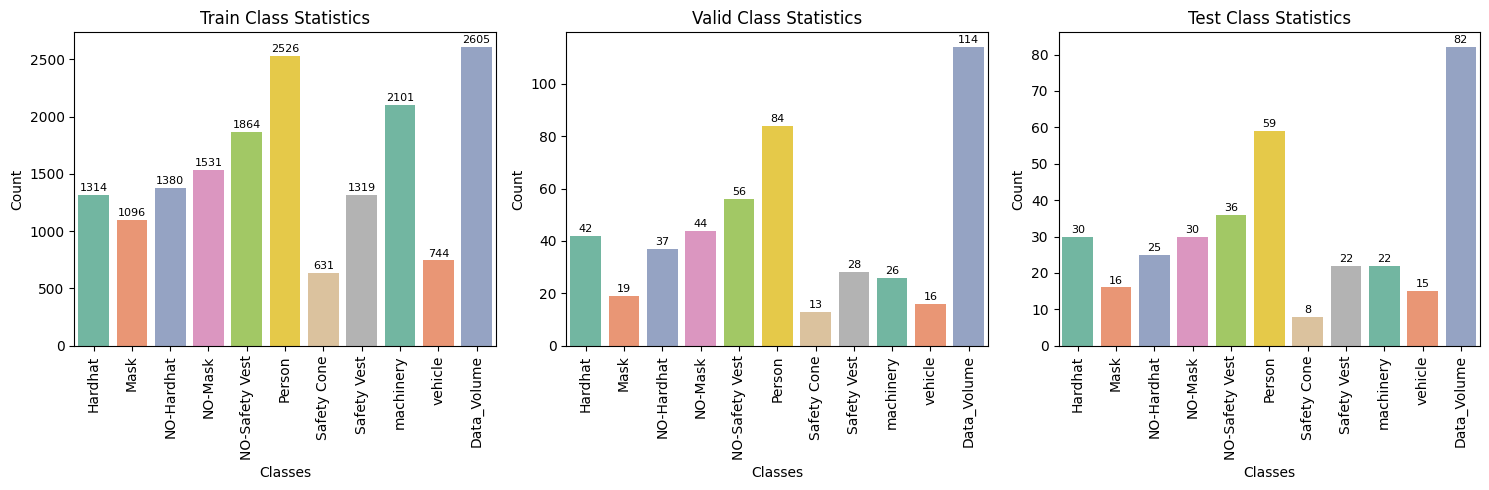

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 3 графіки в ряд (train/valid/test)

for i, mode in enumerate(['train', 'valid', 'test']):
    sns.barplot(
        data=dataset_stats_df[dataset_stats_df['Mode'] == mode].drop(columns='Mode'),
        orient='v',      # Вертикальні стовпці
        ax=axes[i],      # Малюємо на i-й осі
        palette='Set2'   # Палітра кольорів
    )

    axes[i].set_title(f'{mode.capitalize()} Class Statistics')  # Заголовок
    axes[i].set_xlabel('Classes')   # Підпис осі X
    axes[i].set_ylabel('Count')     # Підпис осі Y
    axes[i].tick_params(axis='x', rotation=90)  # Назви класів вертикально (не перекриваються)

    # Додаємо числові підписи над кожним стовпцем
    for p in axes[i].patches:
        axes[i].annotate(
            f"{int(p.get_height())}",  # Значення: висота стовпця = кількість
            (p.get_x() + p.get_width() / 2., p.get_height()),  # Позиція підпису
            ha='center', va='center', fontsize=8,
            color='black', xytext=(0, 5), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

In [ ]:
# Завантажуємо попередньо навчену модель YOLOv9e
# При першому запуску файл .pt автоматично завантажується з ultralytics servers
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

# Запускаємо inference на тестовому зображенні
results = model.predict(
    source=example_image_path,  # Шлях до вхідного зображення
    classes=[0],                # Детектуємо тільки клас 0: Person (з COCO)
    conf=0.30,                  # Поріг впевненості: відкидаємо рамки з confidence < 0.30
    device=None,                # None = CPU; [0] = перша GPU; [0, 1] = дві GPU
    imgsz=(                     # Розмір входу для моделі (висота, ширина)
        img_properties['height'],
        img_properties['width']
    ),
    save=True,                  # Зберегти зображення з намальованими рамками
    save_txt=True,              # Зберегти анотації у форматі YOLO .txt
    save_conf=True,             # Додати confidence score до збережених анотацій
    exist_ok=True,              # Не кидати помилку, якщо директорія вже існує
)

# Відображаємо результат inference
example_image_inference_output = example_image_path.split('/')[-1]
display_image(f'runs/detect/predict/{example_image_inference_output}')

In [ ]:
# Завантажуємо базову модель з претренованими вагами COCO
model = YOLO(CFG.BASE_MODEL_WEIGHTS)

In [ ]:
%%time

model.train(
    # --- Дані ---
    data=os.path.join(CFG.OUTPUT_DIR, 'data.yaml'),  # Шлях до конфігурації датасету
    task='detect',  # Задача: 'detect' (bounding boxes), або 'segment', 'classify', 'pose'

    # --- Розмір вхідного зображення ---
    imgsz=(img_properties['height'], img_properties['width']),  # (640, 640)

    # --- Параметри навчання ---
    epochs=CFG.EPOCHS,           # Кількість епох (70 для повного тренування)
    batch=CFG.BATCH_SIZE,        # Розмір батчу (зменшити при нестачі GPU-пам'яті)
    optimizer=CFG.OPTIMIZER,     # 'auto': ultralytics підбирає автоматично
    lr0=CFG.LR,                  # Початковий learning rate: 0.001
    lrf=CFG.LR_FACTOR,           # Кінцевий lr = lr0 * lrf: 0.001 * 0.01 = 0.00001
    weight_decay=CFG.WEIGHT_DECAY,   # L2-регуляризація: 0.0005
    dropout=CFG.DROPOUT,             # Dropout: 0.0 (вимкнено)
    fraction=CFG.FRACTION,           # Частка датасету: 1.0 = всі дані
    patience=CFG.PATIENCE,           # Early stopping через 20 епох без покращення
    profile=CFG.PROFILE,             # Профілювання швидкості (False — вимкнено)
    label_smoothing=CFG.LABEL_SMOOTHING,  # Розм'якшення міток (0.0 — вимкнено)

    # --- Метадані ---
    name=f'{CFG.BASE_MODEL}_{CFG.EXP_NAME}',  # Назва директорії для збереження результатів
    seed=CFG.SEED,    # Seed для відтворюваності

    # --- Додаткові параметри ---
    val=True,         # Валідувати після кожної епохи
    amp=True,         # AMP (Automatic Mixed Precision): прискорює тренування на GPU
    exist_ok=True,    # Перезаписати директорію результатів, якщо вже існує
    resume=False,     # False = починати з нуля; True = продовжити з checkpoint
    device=[0, 1],       # [0] — перша GPU; [0, 1] — дві GPU; None — CPU
    verbose=False,    # False — мінімальний вивід у консоль
)

In [ ]:
import os
import shutil

run_dir = f"/kaggle/working/deep/runs/detect/{CFG.BASE_MODEL}_{CFG.EXP_NAME}/weights"

best_src = os.path.join(run_dir, "best.pt")
last_src = os.path.join(run_dir, "last.pt")

best_dst = "/kaggle/working/best.pt"
last_dst = "/kaggle/working/last.pt"

shutil.copy2(best_src, best_dst)
shutil.copy2(last_src, last_dst)

print("Saved:")
print(best_dst)
print(last_dst)

In [ ]:
# Після тренування — завантажуємо найкращі ваги
model = YOLO('/kaggle/working/best.pt')

# Експортуємо модель у формат ONNX
model.export(
    format='onnx',   # Цільовий формат: onnx, openvino, engine (TensorRT), tflite тощо
    imgsz=(img_properties['height'], img_properties['width']),  # Розмір входу
    half=False,      # False: FP32 (повна точність); True: FP16 (менший розмір, швидше)
    int8=False,      # False: не квантизувати до INT8
    simplify=False,  # False: не спрощувати граф ONNX (зберегти повну структуру)
    nms=False,       # False: NMS виконується поза ONNX (у постобробці)
)

In [ ]:
# Перевіряємо, чи збереглися файли моделі після тренування.
# Команда показує:
# - назву файлу
# - його розмір
# - дату створення

!ls -lh /kaggle/working/*.pt
!ls -lh /kaggle/working/*.onnx

In [26]:
# Об'єднуємо три важливі файли моделі в один ZIP-архів,
# щоб їх було зручніше завантажити з Kaggle і зберегти локально.

!zip -j /kaggle/working/yolo_models.zip \
    /kaggle/working/best.pt \
    /kaggle/working/last.pt \
    /kaggle/working/best.onnx

  adding: best.pt (deflated 8%)
  adding: last.pt (deflated 8%)
  adding: best.onnx (deflated 18%)


In [27]:
# Перевіряємо, що ZIP-архів успішно створений
# і дивимося його розмір.

!ls -lh /kaggle/working/yolo_models.zip

-rw-r--r-- 1 root root 387M Sep 14 10:58 /kaggle/working/yolo_models.zip


In [ ]:
# Після того, як модель навчена, збережена і ваги вже існують,
# щоб відновити сесію потрібно:

# 0) Відновити робочу папку проєкту
!rm -rf deep
!git clone https://github.com/PetraStill/deep.git
%cd deep

In [29]:
# 1) Перевірити, що ваги доступні (якщо раніше копіювала у /kaggle/working)
!ls -lh /kaggle/working/*.pt
!ls -lh /kaggle/working/*.onnx

# Якщо вони не доступні, то з правого боку натиснути Upload -> new dataset -> обрати файл з ноута best.pt і завантаж

ls: cannot access '/kaggle/working/*.pt': No such file or directory
ls: cannot access '/kaggle/working/*.onnx': No such file or directory
/kaggle/working/deep/deep/deep/deep
total 24K
drwxr-xr-x  5 root root 4.0K Sep 14 20:45 .
drwxr-xr-x  5 root root 4.0K Sep 14 20:32 ..
-rw-r--r--  1 root root  258 Sep 14 20:43 data.yaml
drwxr-xr-x 10 root root 4.0K Sep 14 20:53 deep
drwxr-xr-x  2 root root 4.0K Sep 14 20:32 .virtual_documents
drwxr-xr-x  2 root root 4.0K Sep 14 20:42 wandb


## Тема 8. Аналіз результатів навчання YOLO

У попередній темі модель YOLO була навчена на датасеті Construction Site Safety.

Kaggle використовує тимчасове середовище `/kaggle/working`.
Після завершення або перезапуску сесії файли з цієї директорії можуть зникнути.

Тому після тренування важливо окремо зберегти:

- `best.pt` — найкращі ваги моделі;
- `last.pt` — ваги останньої епохи;
- `best.onnx` — експортовану модель;
- результати тренування з папки `runs/detect/...`.

У нашому випадку попередня Kaggle-сесія вже завершилась.
Файл `best.pt` був збережений окремо і завантажений назад у Kaggle як Dataset/Input.

Тому зараз ми:
1. завантажимо збережену модель;
2. повторно запустимо validation;
3. заново створимо основні графіки та метрики;
4. проаналізуємо результати моделі.

In [49]:
# Встановлюємо бібліотеку Ultralytics.
# Вона містить клас YOLO і всі необхідні інструменти
# для завантаження, validation та аналізу моделі.

!pip install -q ultralytics

In [50]:
# Імпортуємо інструменти, які будемо використовувати далі.

from ultralytics import YOLO  # Робота з YOLO-моделями
import os                     # Робота з файлами і шляхами
import glob                   # Пошук файлів за шаблоном
import yaml                   # Робота з YAML-конфігураціями
import matplotlib.pyplot as plt
from PIL import Image

In [51]:
# Завантажуємо найкращу версію навченої YOLO-моделі.
# Цей файл був збережений після попереднього тренування
# і зараз підключений до Kaggle як Input.

model_path = '/kaggle/input/datasets/petrastill/yolo-best-pt/best.pt'

model = YOLO(model_path)

In [52]:
# YOLO потрібно знати:
# - де знаходяться train/validation/test зображення;
# - скільки є класів;
# - як називається кожен клас.
#
# Для цього створюємо файл data.yaml.

data = {
    'train': '/kaggle/working/deep/тема_7/train/images',
    'val': '/kaggle/working/deep/тема_7/valid/images',
    'test': '/kaggle/working/deep/тема_7/test/images',

    'nc': 10,

    'names': [
        'Hardhat',
        'Mask',
        'NO-Hardhat',
        'NO-Mask',
        'NO-Safety Vest',
        'Person',
        'Safety Cone',
        'Safety Vest',
        'machinery',
        'vehicle'
    ]
}

# Записуємо словник у YAML-файл
data_yaml_path = '/kaggle/working/data.yaml'

with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data, f)

print('data.yaml створено:', data_yaml_path)

data.yaml створено: /kaggle/working/data.yaml


In [53]:
# Перевіряємо, що саме записано у data.yaml

!cat /kaggle/working/data.yaml

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: "/kaggle/working/deep/\u0442\u0435\u043C\u0430_7/test/images"
train: "/kaggle/working/deep/\u0442\u0435\u043C\u0430_7/train/images"
val: "/kaggle/working/deep/\u0442\u0435\u043C\u0430_7/valid/images"


In [54]:
# Запускаємо validation вже навченої моделі.
#
# Важливо:
# модель НЕ тренується повторно.
# Її ваги НЕ змінюються.
#
# Ми лише показуємо їй validation dataset
# і просимо порахувати метрики якості.

metrics = model.val(
    data=data_yaml_path,
    imgsz=640,
    plots=True,

    # Явно задаємо папку, куди записати нові результати
    project='/kaggle/working/topic8_results',
    name='validation'
)

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv9e summary (fused): 279 layers, 57,384,110 parameters, 0 gradients, 189.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1149.8±555.7 MB/s, size: 51.7 KB)
val: Scanning /kaggle/working/deep/тема_7/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 1.3Kit/s 0.1s
val: New cache created: /kaggle/working/deep/тема_7/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2s/it 9.6s1.2ss
                   all        114        697      0.934      0.811      0.868      0.602
               Hardhat         42         79       0.97      0.807      0.934      0.646
                  Mask         19         21          1      0.933      0.955      0.744
            NO-Hardhat         37         69      0.934       0.71      0.814      0.482
               NO-Mask         44         74      0.

In [55]:
# Дивимося всі файли, які YOLO створив після validation.

!find /kaggle/working/topic8_results/validation -maxdepth 1 -type f

/kaggle/working/topic8_results/validation/BoxP_curve.png
/kaggle/working/topic8_results/validation/confusion_matrix.png
/kaggle/working/topic8_results/validation/BoxR_curve.png
/kaggle/working/topic8_results/validation/val_batch2_labels.jpg
/kaggle/working/topic8_results/validation/BoxF1_curve.png
/kaggle/working/topic8_results/validation/val_batch1_pred.jpg
/kaggle/working/topic8_results/validation/val_batch0_pred.jpg
/kaggle/working/topic8_results/validation/confusion_matrix_normalized.png
/kaggle/working/topic8_results/validation/BoxPR_curve.png
/kaggle/working/topic8_results/validation/val_batch0_labels.jpg
/kaggle/working/topic8_results/validation/val_batch2_pred.jpg
/kaggle/working/topic8_results/validation/val_batch1_labels.jpg


In [56]:
# Знаходимо всі PNG і JPG файли,
# які YOLO створив під час validation.
#
# Виключаємо файли з "batch" у назві,
# бо зараз нас цікавлять саме графіки метрик.

results_paths = [
    file_path
    for file_path in
    glob.glob('/kaggle/working/topic8_results/validation/*.png') +
    glob.glob('/kaggle/working/topic8_results/validation/*.jpg')
    if 'batch' not in file_path
]

print('Знайдено файлів:', len(results_paths))

results_paths

Знайдено файлів: 6


['/kaggle/working/topic8_results/validation/BoxP_curve.png',
 '/kaggle/working/topic8_results/validation/confusion_matrix.png',
 '/kaggle/working/topic8_results/validation/BoxR_curve.png',
 '/kaggle/working/topic8_results/validation/BoxF1_curve.png',
 '/kaggle/working/topic8_results/validation/confusion_matrix_normalized.png',
 '/kaggle/working/topic8_results/validation/BoxPR_curve.png']

/kaggle/working/topic8_results/validation/BoxF1_curve.png


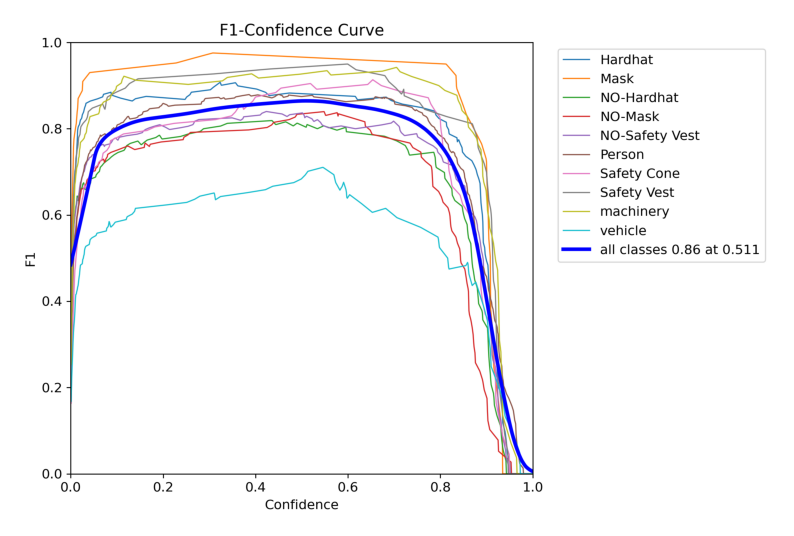

/kaggle/working/topic8_results/validation/BoxPR_curve.png


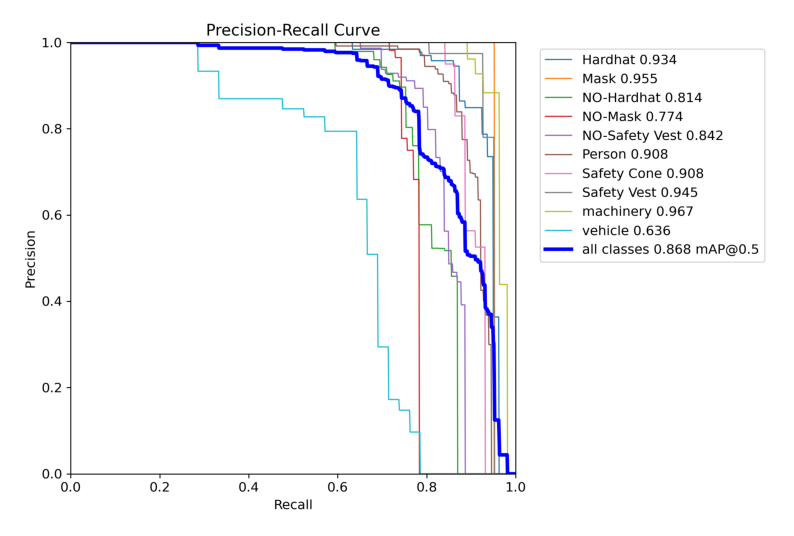

/kaggle/working/topic8_results/validation/BoxP_curve.png


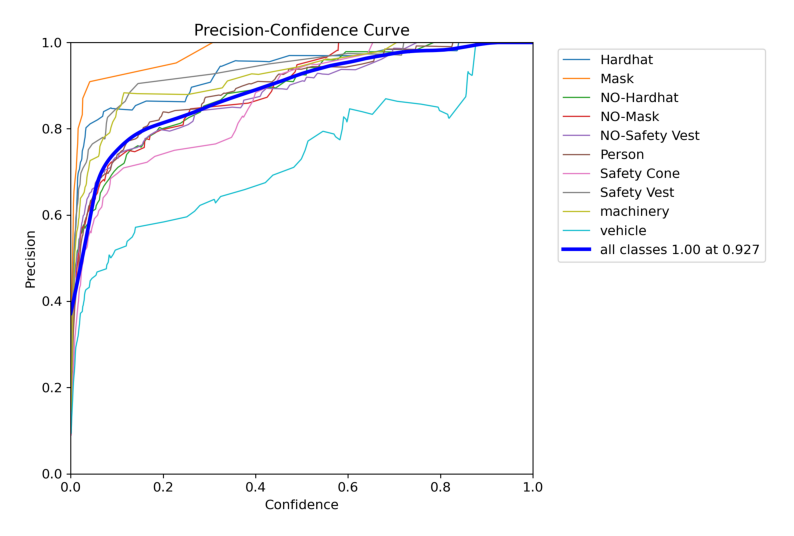

/kaggle/working/topic8_results/validation/BoxR_curve.png


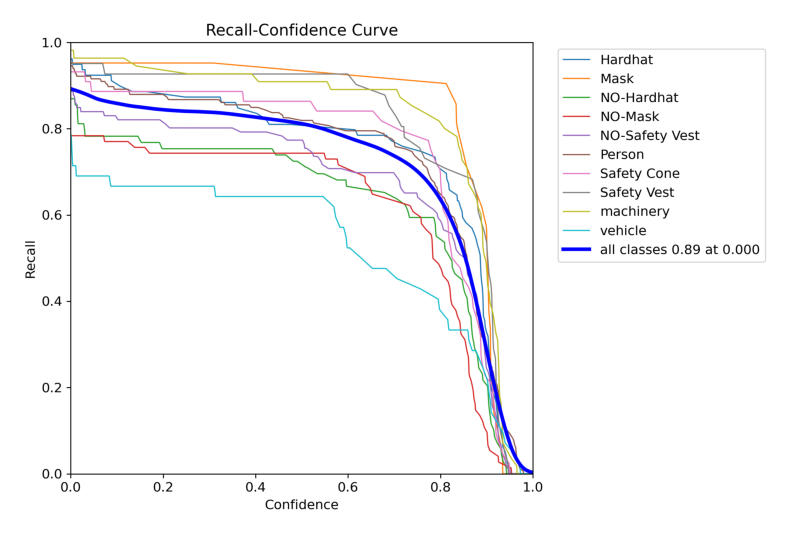

/kaggle/working/topic8_results/validation/confusion_matrix.png


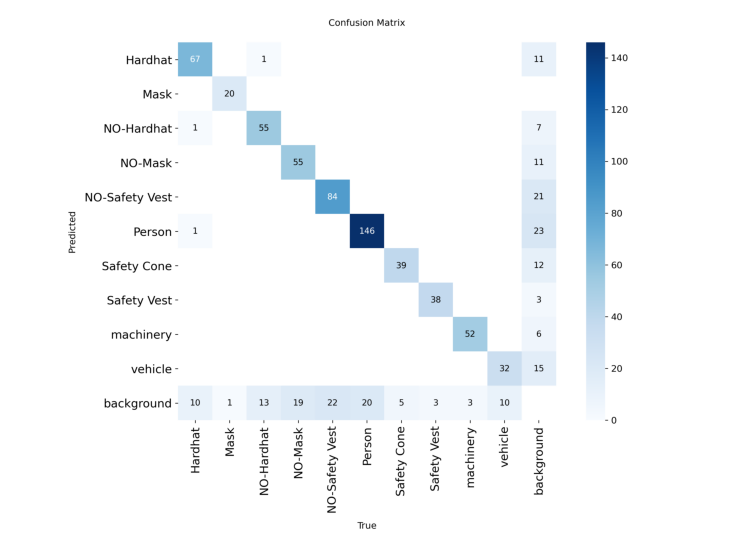

/kaggle/working/topic8_results/validation/confusion_matrix_normalized.png


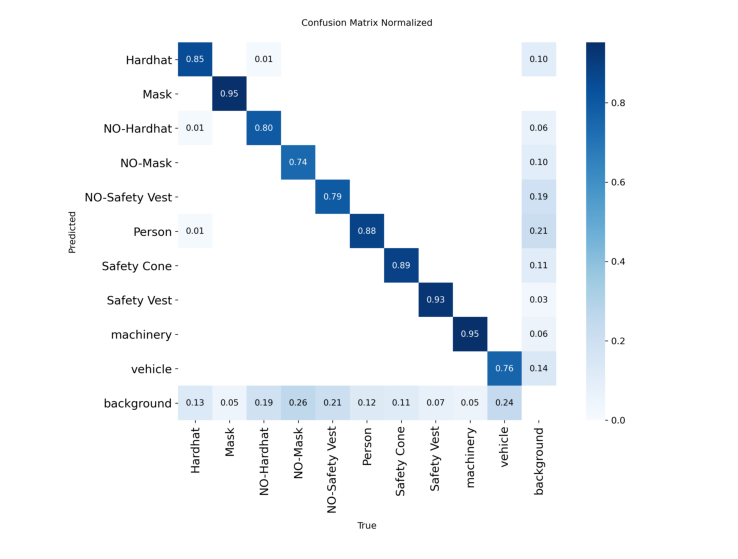

In [57]:
# Відображаємо знайдені графіки один за одним.

for file_path in sorted(results_paths):

    print(file_path)

    img = Image.open(file_path)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

---

## Бонус. Статистика датасету і корелограма (власний код)

Два графіки, які YOLO малює автоматично під час тренування —
`labels.jpg` і `labels_correlogram.jpg` — **не відновлюються** через `model.val(plots=True)`.
Вони будуються на самому старті навчання зі статистики розмітки.

Але відтворити їх **просто**: вся потрібна інформація лежить у текстових файлах розмітки,
які вже є у клонованому репозиторії. Модель і GPU для цього не потрібні.

**Формат файлу розмітки.** На кожне зображення є `.txt` файл у папці `labels/`.
Кожен рядок — один об'єкт, п'ять чисел через пробіл:

```text
5 0.504687 0.464844 0.109784 0.148438
│    x        y      ширина  висота
└─ номер класу (5 = Person)
```

Усі чотири координати **нормалізовані** — це частки від розміру зображення (0 до 1).
Тому розмітка однакова незалежно від роздільної здатності зображення.

In [ ]:
# Для корелограми потрібні glob, os, pandas, seaborn і matplotlib.
# Всі вони є у Kaggle за замовчуванням — pip install не потрібен.
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Папка з файлами розмітки тренувальної вибірки.
labels_dir = '/kaggle/working/deep/тема_7/train/labels'

# Порядок класів — як у data.yaml: індекс у списку = номер класу.
class_names = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
    'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle',
]

rows = []  # Тут накопичуємо всі об'єкти з усіх файлів

# glob.glob знаходить усі .txt файли в папці
for txt_path in glob.glob(os.path.join(labels_dir, '*.txt')):
    with open(txt_path) as f:
        for line in f:
            parts = line.split()

            # Захист від порожніх або пошкоджених рядків
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x, y, w, h = (float(v) for v in parts[1:])

            rows.append({
                'class_id':   class_id,
                'class_name': class_names[class_id],
                'x': x, 'y': y, 'width': w, 'height': h,
            })

df = pd.DataFrame(rows)

print('Файлів розмітки:', len(glob.glob(os.path.join(labels_dir, '*.txt'))))
print("Всього об'єктів:", len(df))
df.head()


In [ ]:
# Кількість об'єктів по класах — аналог labels.jpg.

counts = df['class_name'].value_counts()
print(counts)

plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Кількість об'єктів")
plt.title("Кількість об'єктів по класах (train)")
plt.tight_layout()
plt.show()

# Масштаб дисбалансу: найбільший клас / найменший
print(f'\nНайбільший клас перевищує найменший у {counts.iloc[0] / counts.iloc[-1]:.1f} разів')


In [ ]:
# Корелограма: матриця попарних графіків для x, y, width, height.
#
# diag_kind='hist'   → на діагоналі гістограми розподілу кожного параметра
# s=5, alpha=0.2     → дрібні напівпрозорі точки (їх ~37 тис., без прозорості
#                      всі злилися б в одну пляму)

g = sns.pairplot(
    df[['x', 'y', 'width', 'height']],
    diag_kind='hist',
    plot_kws={'s': 5, 'alpha': 0.2},
)

g.figure.suptitle('Labels Correlogram', y=1.01)
plt.show()

# Числова кореляція між шириною і висотою.
# 1.0 = ідеально разом, 0 = ніякого зв'язку.
print('Кореляція width/height:', round(df['width'].corr(df['height']), 3))


In [ ]:
# Числові характеристики параметрів рамок.
# describe() дає середнє, медіану (50%), мінімум, максимум і квартилі.

print(df[['x', 'y', 'width', 'height']].describe())

# Частка дрібних об'єктів (менших за 0.2 по обох вимірах).
# .mean() від True/False = частка True.
small_share = ((df['width'] < 0.2) & (df['height'] < 0.2)).mean()
print(f"\nЧастка об'єктів, дрібніших за 0.2 по обох вимірах: {small_share:.1%}")


**Як читати результати:**

- **Дисбаланс класів.** `Person` ≈ 9500 об'єктів, `vehicle` ≈ 1500 — різниця приблизно у 6 разів.
  Це пряма причина слабких метрик `vehicle` (AP = 0.636 на PR-кривій).

- **Важкий хвіст ширини і висоти.** Медіана ширини ≈ 0.11, але середнє ≈ 0.18 —
  бо кілька великих об'єктів (техніка) тягнуть середнє вгору.
  Близько половини всіх об'єктів дрібніші за 0.2 по обох вимірах.

- **Висота в середньому більша за ширину** — логічно: найчисленніший клас це люди,
  а вони вертикальні.

- **Трикутники на графіках `x` vs `width` і `y` vs `height`** — це геометричне обмеження:
  рамка мусить уміститись у кадр. Якщо центр об'єкта на краю (`x ≈ 0`),
  рамка не може бути широкою. Максимальна ширина = `2 × min(x, 1-x)`.
  Точки **за** межами трикутника означали б помилку в розмітці.